## Final avaition and legal network - based on Elias's nb + Lowie's earlier work

### (1) PART 1: ACTUAL CELLS TO RUN 
For explanation on how all these elements were obtained - see PART 2 under

In [ ]:
# imports
from neo4j import GraphDatabase
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import networkx as nx
import scipy
from IPython.display import Image, display
import seaborn as sns

In [35]:
# connection to graph
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("", ""))

In [36]:
# creation of functions for easy Cypher running via VSC

def run_query(cypher):
    """Run a Cypher query and return results as a pandas DataFrame."""
    with driver.session() as session:
        result = session.run(cypher)
        return pd.DataFrame([dict(r) for r in result])

# Verify connection and confirm full import
counts = run_query("""
    MATCH (n) RETURN count(n) AS node_count
""")
edge_counts = run_query("""
    MATCH ()-[r]->() RETURN count(r) AS edge_count
""")
print(f"Connected to Memgraph.")
print(f"Nodes : {counts['node_count'][0]:,}  (expected 546,648)")
print(f"Edges : {edge_counts['edge_count'][0]:,}  (expected 1,432,277)")

Connected to Memgraph.
Nodes : 546,648  (expected 546,648)
Edges : 1,432,277  (expected 1,432,277)


In [37]:
# for use of python lists with Cypher
def to_cypher_list(lst):
    return '[' + ', '.join(f'"{item}"' for item in lst) + ']'

In [38]:
## LISTS DEFIENED FOR ELABORATION AVIATON AND LEGAL NETWORKS

# (1) EPSTEIN NAMES - defining all names for epstein (all nodes we identified that represent Epstein)
EPSTEIN_NAMES = ["Jeffrey Epstein", "Jeff Epstein", "Epstein"]

# (2) LEGAL KEYWORDS
LEGAL_KEYWORDS = [
    # Criminal law
    'pleaded guilty',
    'indicted',
    'convicted',
    'sentenced',
    'arrested',
    'prosecuted',
    'charged',
    'prison sentence',
    'sex offender',
    'accused',
    # Non-prosecution
    'non-prosecution',
    'plea deal',
    'plea bargain',
    # Civil law
    'sued',
    'lawsuit',
    'filed suit',
    'filed complaint',
    'filed civil',
    'filed defamation',
    'filed claim',
    'filed federal',
    'civil action against',
    'defamation claim',
    'defamation action',
    'federal civil suit',
    'settled',
    # Procedural
    'subpoena',
    'deposition',
    'attempted to depose',
    'deposed',
    'filed motion',
    'filed counterclaim',
    'filed bar complaint',
    'filed allegations',
    'filed response',
    'introduce evidence',
    'exclusion of evidence',
    'argued before',
    # Testimonies
    'testimony',
    'testified before',
    'investigated',
    'accused',
    'questioned',
    # Fifth Amendment
    'fifth amendment',
    'self-incrimination',
    'took the fifth',
    # Immunity
    'granted immunity',
    'received immunity',
    'agreed not to prosecute',
]

# (3) AVIATION ACTIONS
AVIATION_ACTIONS = [
    # Core travel with person
    'traveled with',
    'traveled_with',
    'travelled with',
    'accompanied',
    'accompanied by',
    'traveled to Little St James with',
    'traveled with to multiple residences',
    'traveled with on private plane',
    'traveled to Caribbean location with',
    'traveled to Europe with',
    'traveled extensively with',
    'traveled internationally with',
    'traveled internationally on private jet with',
    'traveled by private jet with',
    'traveled on private jet with',
    'traveled on private jet of',
    'traveled on private airplane with',
    'traveled on private plane with',
    'traveled on aircraft with',
    'traveled on jet owned by',
    'traveled on jet of',
    'traveled on flight with',
    'traveled on plane with',
    'traveled on planes in interstate commerce related to',
    'traveled aboard planes and boats of',
    'traveled via private jet of',
    'traveled via private aircraft with',
    'traveled on private aircraft owned by',
    'traveled on aircraft owned by',
    'traveled by helicopter provided by',
    # Flew variants
    'flew',
    'flew with',
    'flew_with',
    'flew on',
    'flew to',
    'flew on jet of',
    'flew on private jet of',
    'flew on private jet owned by',
    'flew on private jet to Africa',
    'flew on private jet',
    'flew on private plane of',
    'flew on airplane of',
    'flew on plane of',
    'flew on plane owned by',
    'flew on plane',
    'flew as passenger on',
    'flew to Africa',
    'flew to Africa with',
    'flew to South Africa with',
    'flew to and represented',
    'flew internationally with',
    'flew internationally to meet',
    'flew two young women to dinner to entertain',
    'flew with as passenger on aircraft owned by',
    'flew Gulfstream to',
    'flew with pilot',
    'allegedly flew',
    'allegedly flew victim to',
    'allegedly flew victims to',
    'allegedly flew to London',
    'allegedly flew for entertainment purposes to',
    # Transported variants
    'transported via private jet',
    'transported on private jet with',
    'transported via private aircraft as',
    'transported to Africa',
    'transported and sexually abused',
    'transported victim via',
    'transported victims via',
    'transported young girls via private aircraft with',
    'transported underage females across state lines using',
    'transported to various properties',
    'transported with',
    'transported to',
    'was transported via private jet by',
    'was transported to residence of',
    'allegedly transported for sexual purposes to',
    'allegedly transported and coerced',
    'allegedly transported victim with',
    'allegedly transported minors on',
    # Aircraft/jet specific
    'entertained on private jet',
    'hosted on private aircraft',
    'provided private jet travel to',
    'provided flights on jets to',
    'provided private jet to',
    'provided private jet for transport of',
    'provided private jet service to',
    'provided transportation via private jet to',
    'provided air transport to',
    'provided aircraft for travel with',
    'provided aircraft to',
    'offered transportation via private jet to',
    'offered jet ride to',
    'offered jet ride',
    'offered jet transport to',
    'offered jet charter to',
    'offered ride to Europe on jet',
    'invited to fly on private jet',
    'flew with as passenger on aircraft owned by',
    'boarded aircraft with',
    'arrived at private aircraft with',
    'ceased flying on aircraft with',
    'chartered private plane to transport guests to',
    'chartered private aircraft for',
    'used jet provided by',
    'used aircraft to transport to Africa',
    'operated Boeing aircraft with',
    'operated private airplane transporting',
    'began international travel with',
    'began traveling with',
    'traveled with Jeffrey Epstein',
    'hosted private jet flight for',
    'stepped away from royal jet and offered BBJ opportunity',
    # Flight log references
    'appears on flight logs with',
    'appeared in flight logs of',
    'appeared_in_flight_logs_of',
    'appeared on flight log with',
    'appeared on flight logs of',
    # Allegedly traveled
    'allegedly traveled with victim to',
    'allegedly arranged helicopter travel for',
    'allegedly instructed to travel and engage in sexual activity with',
    # Recruited and transported
    'recruited and transported to',
    'recruited and transported minors for',
    'recruited and transported girls to',
    'recruited and transported girls for',
    'recruited and transported underage girls for',
    'coordinated recruitment and transport to',
    # added after a second time feeding all actions to claude to verify answer
    'traveled with and attended to',
    'traveled internationally with and exploited for sex acts',
    'traveled to and exploited victims at',
    'traveled to and resided in',
    'traveled to during house arrest on',
    'traveled regularly with',
    'flew on private aircraft owned by',
    'transported on aircraft','hosted and transported to',
    'accepted air travel from',
    'accepted air transportation from',
    'directed to travel to and provide sexual services at',
    'directed to travel to island',
]

# (4) NOISE TERMS
NOISE_TERMS = [
    'jet', 'plane', 'aircraft', 'helicopter', 'island', 'ranch', 'apartment',
    'conference', 'driver', 'therapist',
    'real estate', 'property', 'NU', "victims' rights",'London',
    'multiple properties',
    'sexual assaults',
    'dinner event',
    'modeling agency',
]

In [53]:
# Building of Aviation network 
## step 1 - raw aviation network
df_aviation = run_query(f"""
MATCH (epstein:Entity)-[r:RELATED_TO]-(other:Entity)
WHERE epstein.name IN {to_cypher_list(EPSTEIN_NAMES)}
AND r.action IN {to_cypher_list(AVIATION_ACTIONS)}
WITH other, r, id(r) AS edge_id
WITH other,
     count(DISTINCT edge_id) AS connection_count,
     collect(DISTINCT r.action)[0..5] AS actions_used
RETURN other.name AS entity,
       other.entity_type AS entity_type,
       connection_count,
       actions_used
ORDER BY connection_count DESC
""")
print(f"Total entities: {len(df_aviation)}")
# print(df_aviation.to_string())

Total entities: 92


In [ ]:
## step 2 - aviation network: removal of noise entities from aviation network
def is_noise_entity(name):
    if name is None:
        return True
    name_lower = name.lower()
    return any(term.lower() in name_lower for term in NOISE_TERMS)

aviation_clean = df_aviation[
    ~df_aviation['entity'].apply(is_noise_entity)
].reset_index(drop=True)

print(f"Before noise filter: {len(df_aviation)}")
print(f"After noise filter: {len(aviation_clean)}")
# print(aviation_clean.to_string())

Before noise filter: 92
After noise filter: 69
                                                                            entity            entity_type  connection_count                                                                                                                                                actions_used
0                                                                     Bill Clinton    government official                97                                                 [traveled with on private plane, flew on, traveled with, traveled via private jet of, flew as passenger on]
1                                                                     Kevin Spacey                   None                14                                          [traveled on aircraft with, flew, used aircraft to transport to Africa, flew to South Africa with, flew to Africa]
2                                                                Ghislaine Maxwell              defendant        

In [41]:
## step 3 - aviation network: consolidation of double entities in aviation network
ENTITY_CONSOLIDATION = {
    # Bill Clinton
    'President Clinton': 'Bill Clinton',
    # Alan Dershowitz
    'Professor Dershowitz': 'Alan M. Dershowitz',
    'Alan Dershowitz and Tatiana': 'Alan M. Dershowitz',
    # Lawrence Summers
    'Lawrence Henry Summers': 'Lawrence Summers',
    # Andrés Pastrana
    'Andrés Pastrana': 'Andrés Pastrana Arango',
    # Virginia Giuffre
    'Virginia L. Giuffre': 'Virginia Roberts Giuffre',
    'Virginia': 'Virginia Roberts Giuffre',
    # Thorbjørn Jagland
    'Thorbjorn Jagland': 'Thorbjørn Jagland',
    # Jean-Luc Brunel
    'Jean Luc Brunel': 'Jean-Luc Didier Henri-Rene Brunel',
}

def consolidate_entity(name):
    return ENTITY_CONSOLIDATION.get(name, name)

aviation_clean['entity_consolidated'] = aviation_clean['entity'].apply(consolidate_entity)

# aggregation per consolidated entity
aviation_consolidated = aviation_clean.groupby('entity_consolidated').agg(
    connection_count=('connection_count', 'sum'),
    entity_type=('entity_type', 'first'),
).reset_index().rename(columns={'entity_consolidated': 'entity'})

aviation_consolidated = aviation_consolidated.sort_values('connection_count', ascending=False).reset_index(drop=True)

print(f"Before consolidation: {len(aviation_clean)}")
print(f"After consolidation: {len(aviation_consolidated)}")
print(aviation_consolidated.to_string())

Before consolidation: 69
After consolidation: 60
                                                                            entity  connection_count            entity_type
0                                                                     Bill Clinton               100    government official
1                                                         Virginia Roberts Giuffre                19                 victim
2                                                                     Kevin Spacey                14                   None
3                                                               Alan M. Dershowitz                14          legal counsel
4                                                                Ghislaine Maxwell                14              defendant
5                                                                     Chris Tucker                10                   None
6                                                                 Lawrence Summers 

In [42]:
# Building Legal Network on top of Aviation Network
legal_where = ' OR '.join([
    f"toLower(replace(r.action, '_', ' ')) CONTAINS '{kw}'"
    for kw in LEGAL_KEYWORDS
])

aviation_entities_consolidated = aviation_consolidated['entity'].tolist()

df_legal = run_query(f"""
MATCH (entity:Entity)-[r:RELATED_TO]-(other:Entity)
WHERE entity.name IN {to_cypher_list(aviation_entities_consolidated)}
AND ({legal_where})
RETURN entity.name AS entity,
       count(r) AS legal_count,
       collect(DISTINCT r.action)[0..5] AS legal_actions_sample
ORDER BY legal_count DESC
""")

print(df_legal)

                                               entity  legal_count  \
0                                    unknown person A          317   
1                                  Alan M. Dershowitz          271   
2                                   Ghislaine Maxwell          140   
3                            Virginia Roberts Giuffre          136   
4                                        Donald Trump          107   
5                                        Bill Clinton           27   
6                                        Sarah Kellen           22   
7                                    Nadia Marcinkova           20   
8                         Prince Andrew, Duke of York           19   
9                                     unknown witness           19   
10                  Jean-Luc Didier Henri-Rene Brunel           17   
11                                         Ehud Barak           12   
12                                        Jane Doe #3           11   
13                  

In [43]:
# Bridge nodes

bridge_nodes = aviation_consolidated.merge(
    df_legal,
    on='entity',
    how='left'
).fillna(0)

bridge_nodes['legal_count'] = bridge_nodes['legal_count'].astype(int)
bridge_nodes['total'] = bridge_nodes['connection_count'] + bridge_nodes['legal_count']
bridge_nodes = bridge_nodes.sort_values('total', ascending=False).reset_index(drop=True)

print(f"Total entities with legal connections: {len(df_legal)}")
print(bridge_nodes[['entity', 'connection_count', 'legal_count', 'total']].to_string())

Total entities with legal connections: 27
                                                                            entity  connection_count  legal_count  total
0                                                                 unknown person A                 6          317    323
1                                                               Alan M. Dershowitz                14          271    285
2                                                         Virginia Roberts Giuffre                19          136    155
3                                                                Ghislaine Maxwell                14          140    154
4                                                                     Bill Clinton               100           27    127
5                                                                     Donald Trump                 3          107    110
6                                                      Prince Andrew, Duke of York                 8           

In [44]:
# Extraction subgraph to NetworkX to calculate sociometrics

# extraction aviation network - edges
aviation_entity_list = aviation_consolidated['entity'].tolist()

df_edges_aviation = run_query(f"""
MATCH (a:Entity)-[r:RELATED_TO]-(b:Entity)
WHERE a.name IN {to_cypher_list(aviation_entity_list)}
AND b.name IN {to_cypher_list(aviation_entity_list)}
AND r.action IN {to_cypher_list(AVIATION_ACTIONS)}
RETURN a.name AS source, b.name AS target, r.action AS action, 'aviation' AS edge_type
""")

# extraction of legal network edges
df_edges_legal = run_query(f"""
MATCH (a:Entity)-[r:RELATED_TO]-(b:Entity)
WHERE a.name IN {to_cypher_list(aviation_entity_list)}
AND b.name IN {to_cypher_list(aviation_entity_list)}
AND ({legal_where})
RETURN a.name AS source, b.name AS target, r.action AS action, 'legal' AS edge_type
""")

print(f"Aviation edges between network entities: {len(df_edges_aviation)}")
print(f"Legal edges between network entities: {len(df_edges_legal)}")

Aviation edges between network entities: 52
Legal edges between network entities: 191


In [45]:
# Building NetworkX: 

# combining all edges
df_all_edges = pd.concat([df_edges_aviation, df_edges_legal], ignore_index=True)

# Adding Epstein as central node
epstein_aviation_edges = aviation_consolidated[['entity', 'connection_count']].copy()
epstein_aviation_edges['source'] = 'Jeffrey Epstein'
epstein_aviation_edges['target'] = epstein_aviation_edges['entity']
epstein_aviation_edges['edge_type'] = 'aviation'
epstein_aviation_edges['weight'] = epstein_aviation_edges['connection_count']

# Building of weighted graph
G = nx.Graph()

# Adding of Epstein edges
for _, row in epstein_aviation_edges.iterrows():
    G.add_edge(row['source'], row['target'], 
               weight=row['weight'], 
               edge_type='aviation')

# Adding other edges (weighted by frequence)
for (src, tgt), group in df_all_edges.groupby(['source', 'target']):
    weight = len(group)
    edge_type = group['edge_type'].iloc[0]
    if G.has_edge(src, tgt):
        G[src][tgt]['weight'] += weight
    else:
        G.add_edge(src, tgt, weight=weight, edge_type=edge_type)

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

# Centrality metrics
degree_cent = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G, weight='weight')
closeness_cent = nx.closeness_centrality(G, distance='weight')
pagerank = nx.pagerank(G, weight='weight')

# Summarizing in DF
df_centrality = pd.DataFrame({
    'entity': list(degree_cent.keys()),
    'degree_centrality': list(degree_cent.values()),
    'betweenness_centrality': list(betweenness_cent.values()),
    'closeness_centrality': list(closeness_cent.values()),
    'pagerank': list(pagerank.values()),
}).sort_values('betweenness_centrality', ascending=False).reset_index(drop=True)

print(df_centrality.head(200).to_string())

Nodes: 61
Edges: 85
                                                                            entity  degree_centrality  betweenness_centrality  closeness_centrality  pagerank
0                                                                  Jeffrey Epstein           1.000000                0.977401              0.441176  0.292633
1                                                                 Nadia Marcinkova           0.050000                0.092655              0.320856  0.008345
2                                                                 Adriana Mucinska           0.050000                0.090960              0.319149  0.009199
3                                                      Prince Andrew, Duke of York           0.066667                0.064972              0.206186  0.019361
4                                                                     Bill Clinton           0.133333                0.036158              0.118110  0.131873
5                               

In [ ]:
# Adding column "Category" to entity nodes: 
# (to provide color codes for who is included in legal network vs who is only included in aviation network in Gephi)

# creation of df_nodes, which will be the one to be exported to csv for Gephi - starting from copy of df_centrality 
df_nodes = df_centrality.copy()

# Merging with bridge nodes
df_nodes = df_nodes.merge(
    bridge_nodes[['entity', 'connection_count', 'legal_count', 'total']],
    on='entity', how='left'
).fillna(0)

df_nodes['legal_count'] = df_nodes['legal_count'].astype(int)
df_nodes['connection_count'] = df_nodes['connection_count'].astype(int)

# defining categories (added as feature to entities): epstein, bridge (legal&aviation), aviation only, other: 
def categorize(row):
    if row['entity'] == 'Jeffrey Epstein':
        return 'epstein'
    elif row['connection_count'] > 0 and row['legal_count'] > 0:
        return 'bridge'
    elif row['connection_count'] > 0 and row['legal_count'] == 0:
        return 'aviation_only'
    else:
        return 'other'

df_nodes['category'] = df_nodes.apply(categorize, axis=1)

# actual exporting of CSV file for Gephi
# exporting nodes
df_nodes_gephi = df_nodes.copy()
df_nodes_gephi.insert(0, 'Id', df_nodes_gephi['entity'])
df_nodes_gephi.to_csv('nodes.csv', index=False)
print(df_nodes_gephi.head(3).to_string())
print(f"Nodes exported: {len(df_nodes)}")

# exporting edges
df_edges_export = df_all_edges.groupby(['source', 'target', 'edge_type']).size().reset_index(name='weight')

# Adding of aviation edges epstein to entities
epstein_edges = aviation_consolidated[['entity', 'connection_count']].copy()
epstein_edges.columns = ['target', 'weight']
epstein_edges['source'] = 'Jeffrey Epstein'
epstein_edges['edge_type'] = 'aviation'
df_edges_export = pd.concat([df_edges_export, epstein_edges], ignore_index=True)

df_edges_export_gephi = df_edges_export.rename(columns={
    'source': 'Source',
    'target': 'Target',
    'edge_type': 'edge_type',
    'weight': 'Weight'
})

# adding Type column to edges: 
df_edges_export_gephi['Type'] = 'Undirected'

df_edges_export_gephi.to_csv('edges.csv', index=False)

### (2) PART 2: GEPHI PNG OF NETWORKS + Extra plots for reporting - based on Elias's plots: 

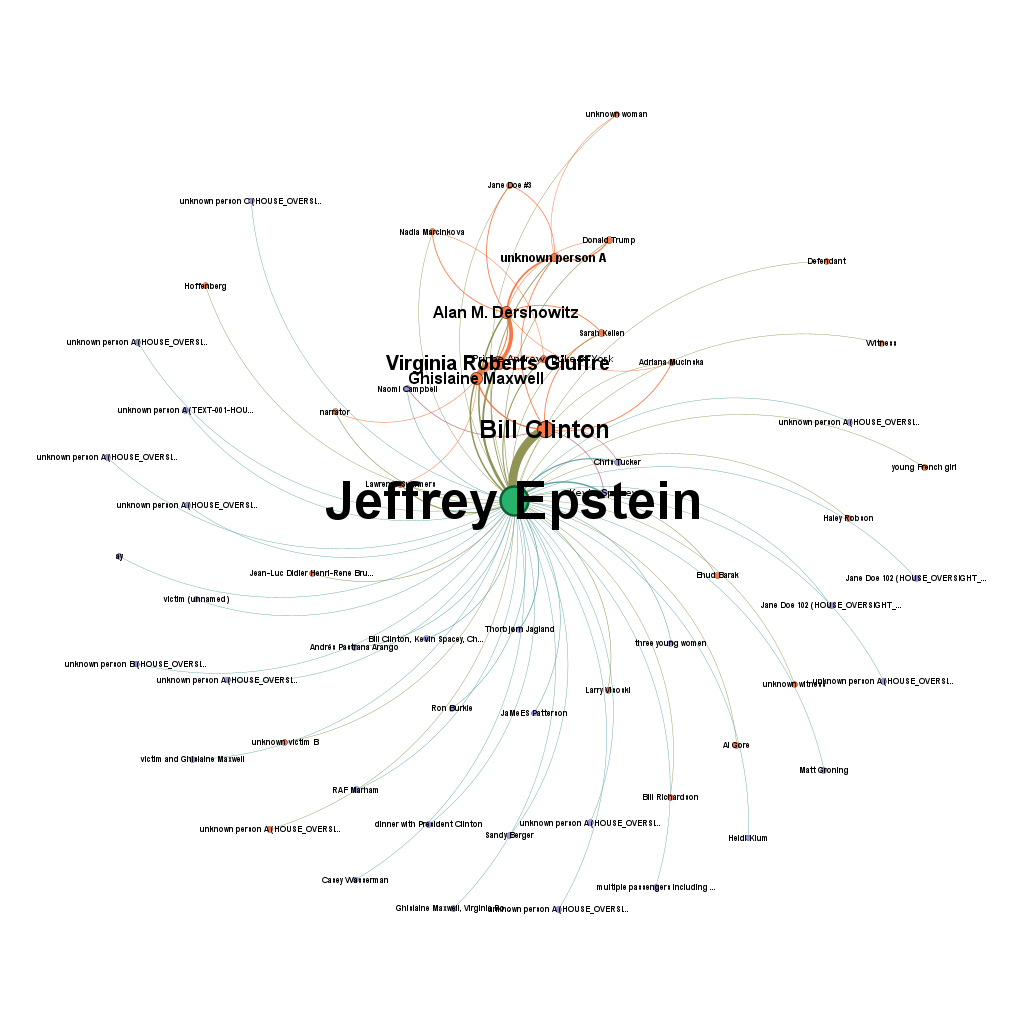

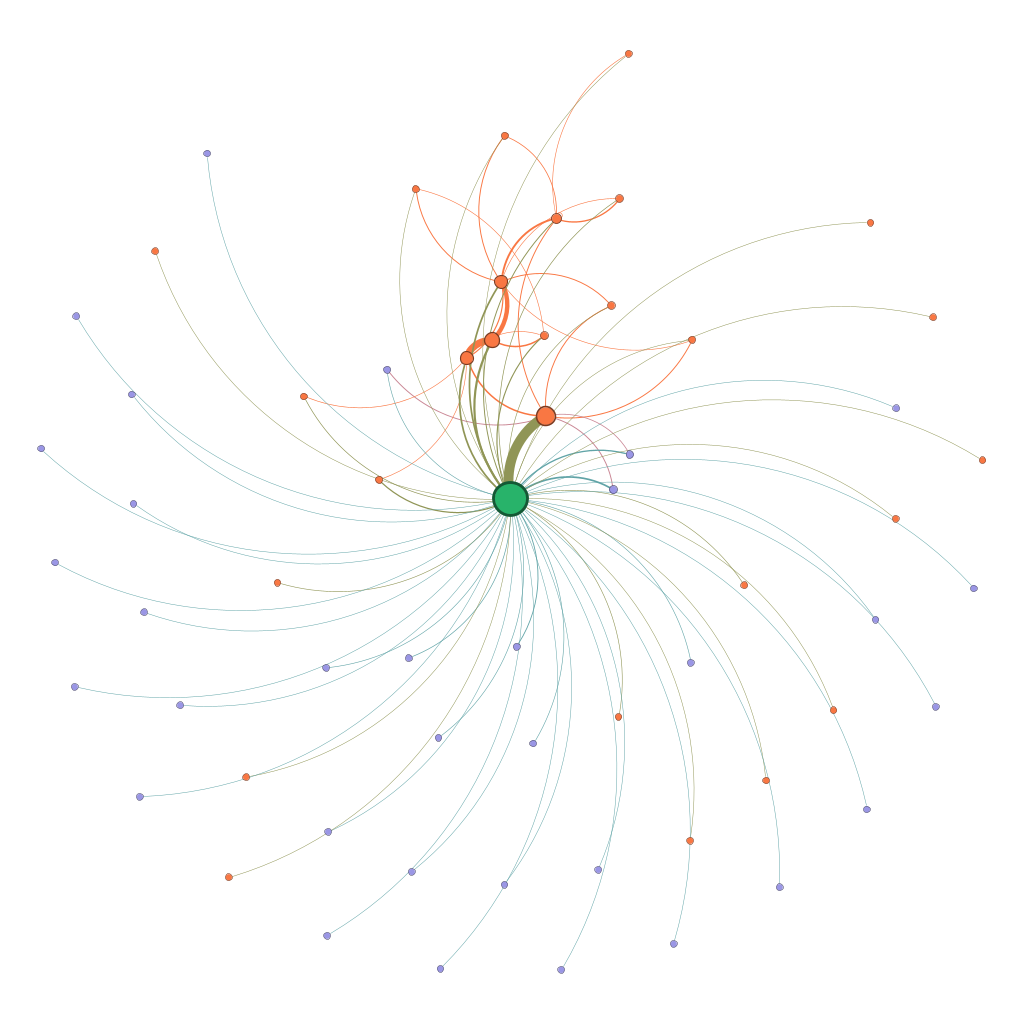

In [65]:
# PNG NETWORK PAGERANK (with and without labels)
display(Image('png_gephi/graph_pagerank_labels.png'))
display(Image('png_gephi/graph_pagerank_no_labels.png'))

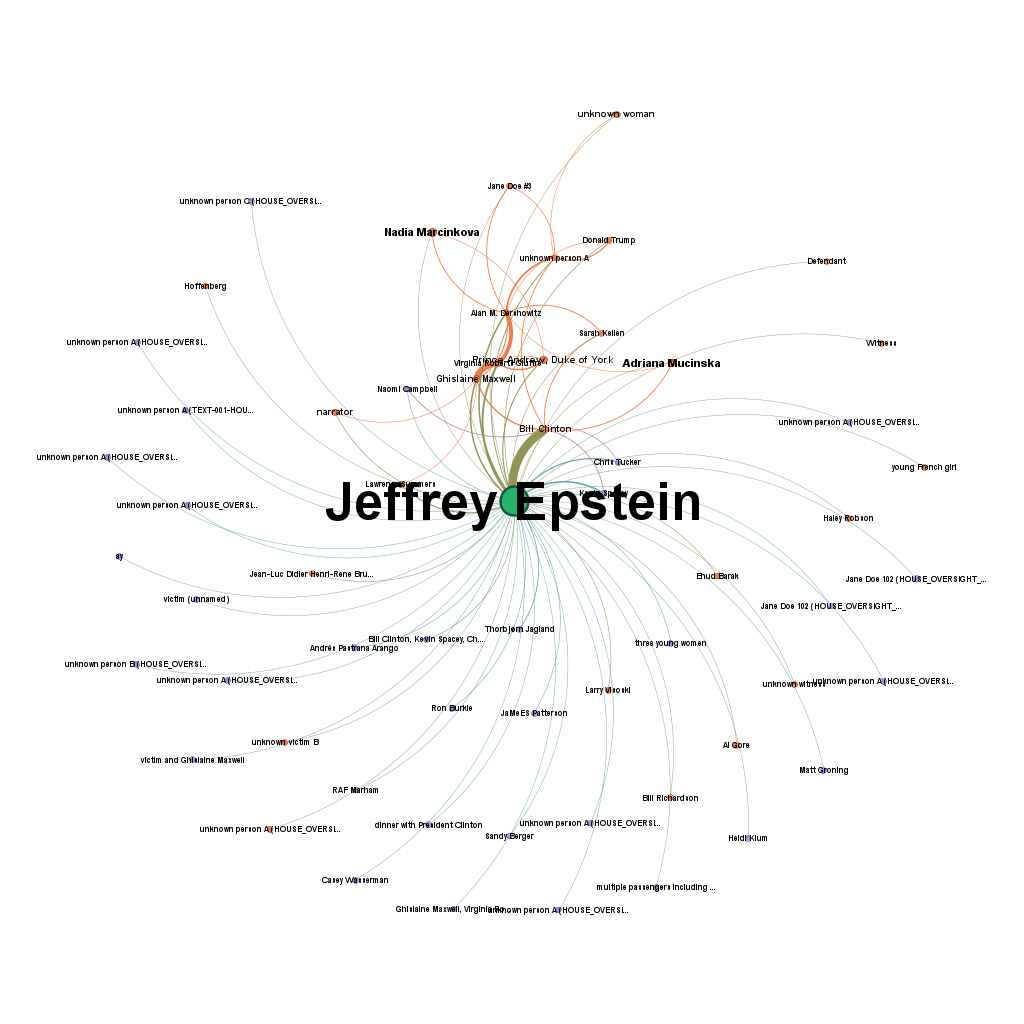

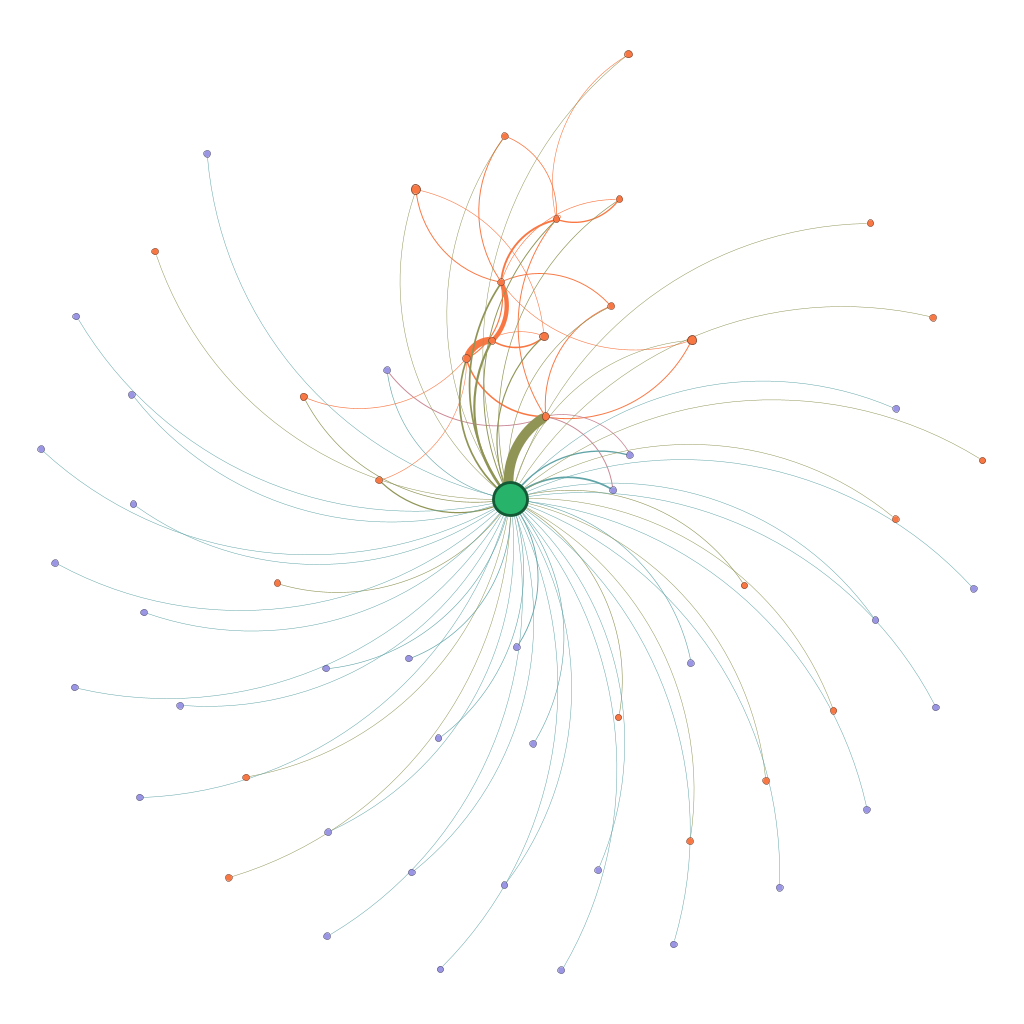

In [66]:
# PNG NETWORK BETWEENNESS (with and without labels)
display(Image('png_gephi/graph_betweenness_labels.png'))
display(Image('png_gephi/graph_betweenness_no_labels.png'))

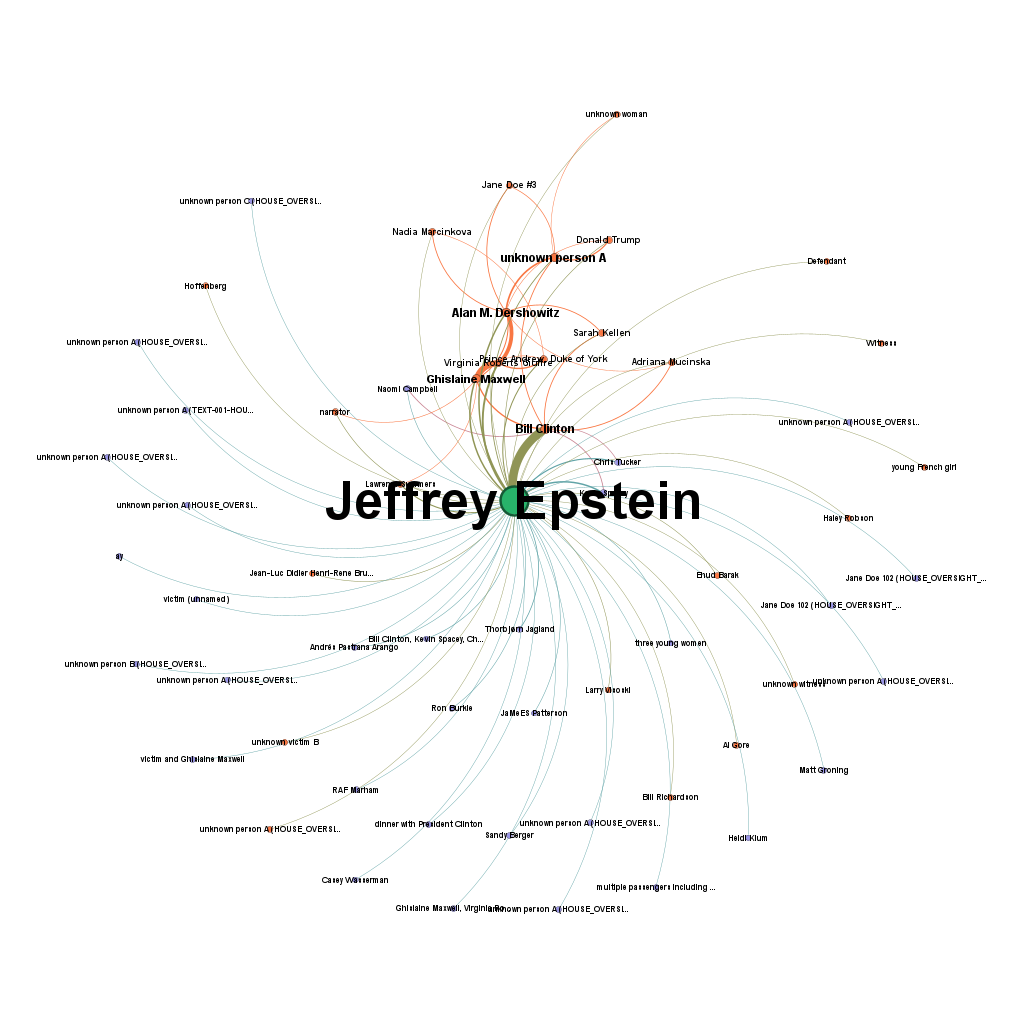

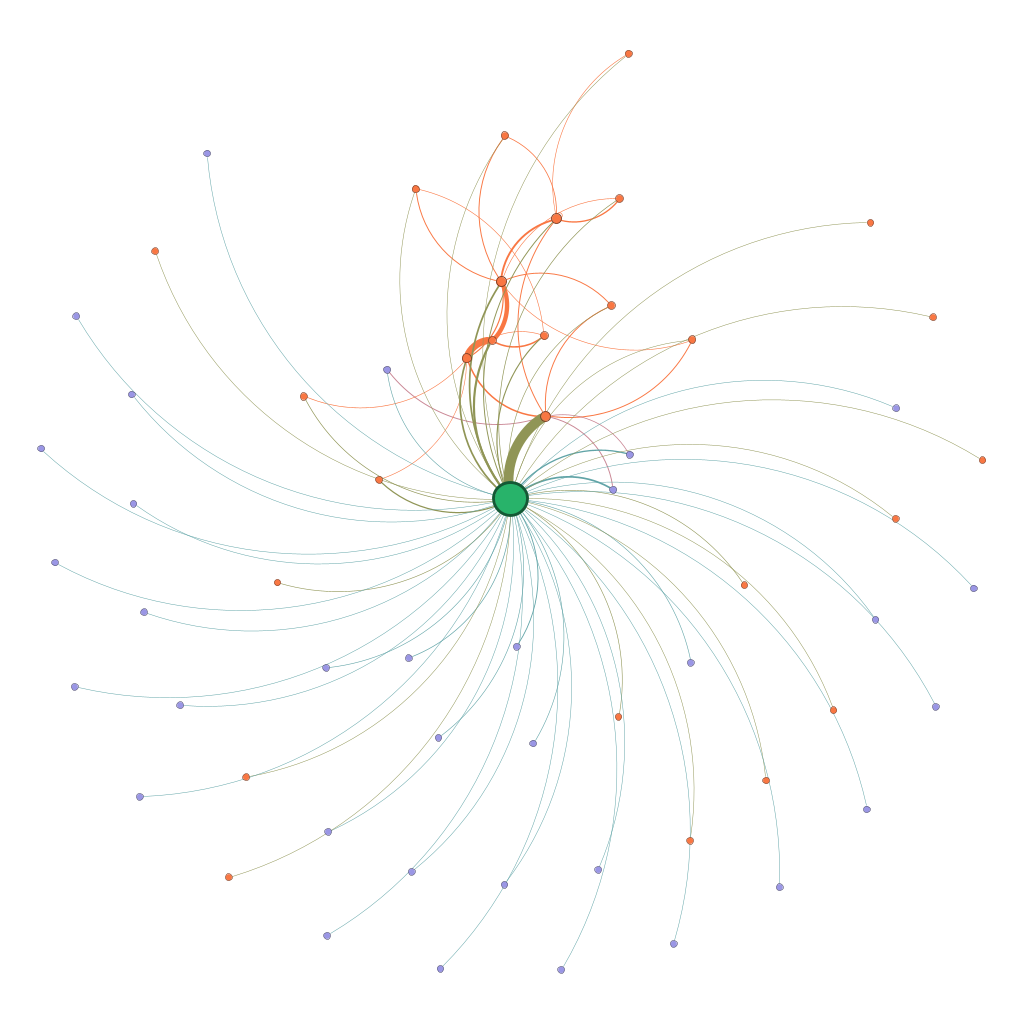

In [67]:
# PNG NETWORK DEGREE (with and without labels)
display(Image('png_gephi/graph_degreecentrality_labels.png'))
display(Image('png_gephi/graph_degreecentrality_nolabels.png'))

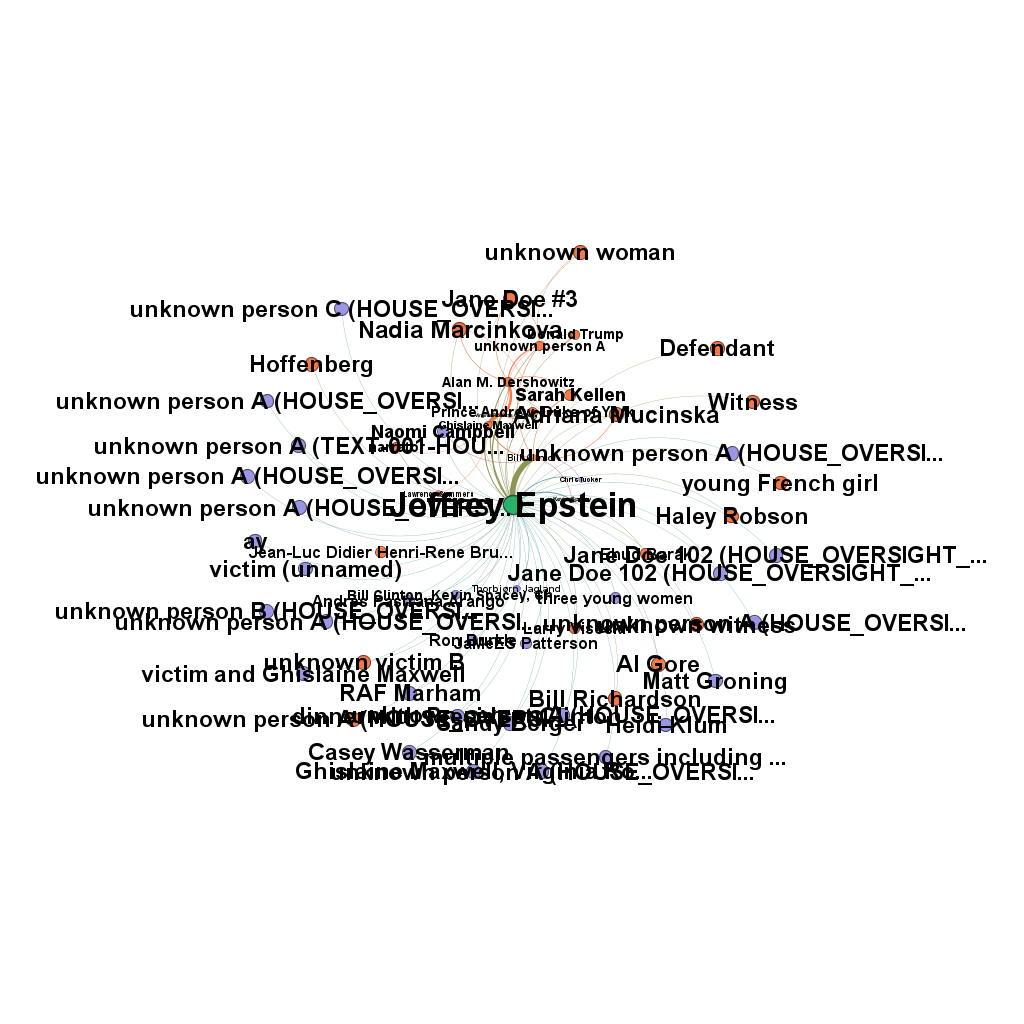

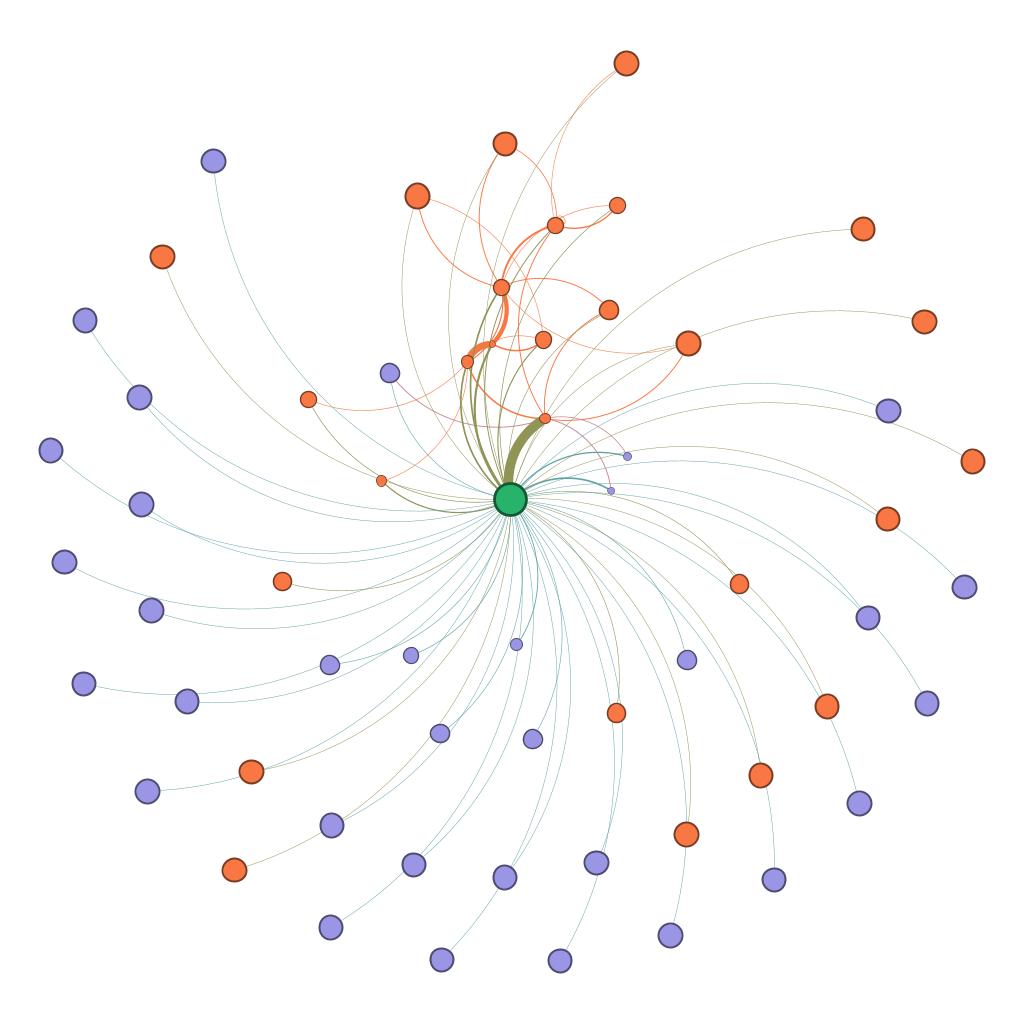

In [68]:
# PNG NETWORK closeness (with and without labels) -
# less interesting (as is a kind of star graph with epstein really in the middle 
# closeness of all quite similar
display(Image('png_gephi/graph_closeness_labels.png'))
display(Image('png_gephi/graph_closeness_no_labels.png'))

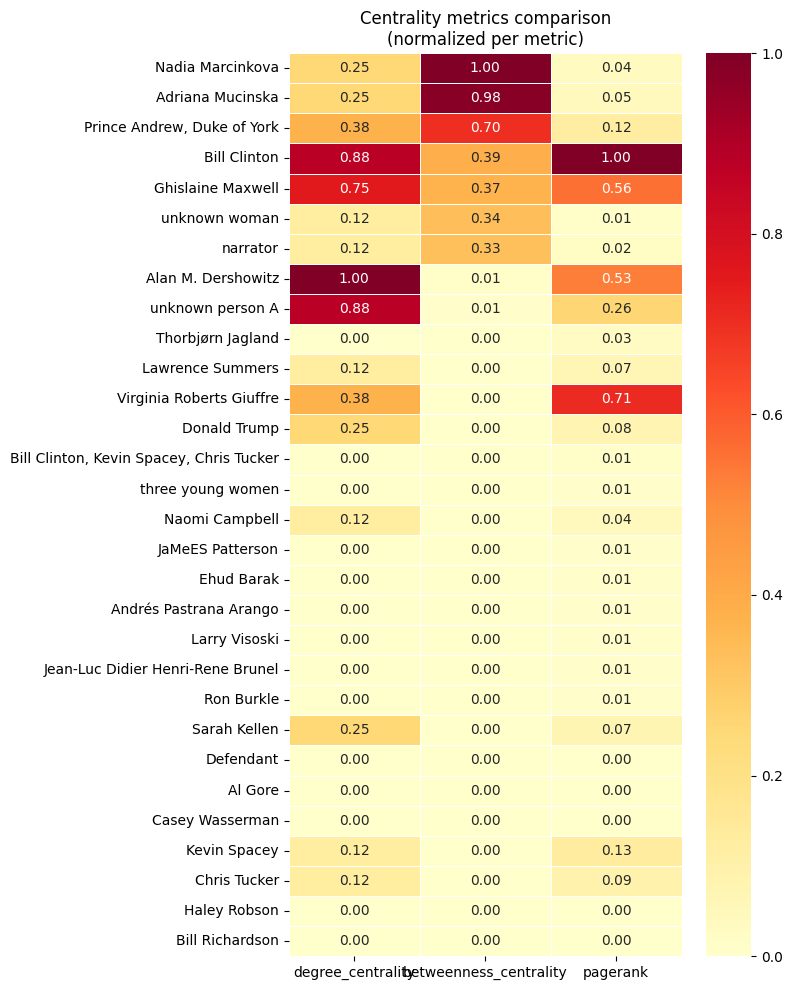

In [63]:
# Heatmap on the centrality metrics (on top 20 of betweenness)
df_heat = df_centrality[df_centrality['entity'] != 'Jeffrey Epstein'].copy()
df_heat = df_heat.head(30)  

# Normalizing metrics 
metrics = ['degree_centrality', 'betweenness_centrality', 'pagerank']
df_heat_norm = df_heat[metrics].copy()
for col in metrics:
    df_heat_norm[col] = (df_heat_norm[col] - df_heat_norm[col].min()) / (df_heat_norm[col].max() - df_heat_norm[col].min())

df_heat_norm.index = df_heat['entity'].values

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(df_heat_norm, 
            annot=True, fmt='.2f',
            cmap='YlOrRd',
            linewidths=0.5,
            ax=ax)
ax.set_title('Centrality metrics comparison\n(normalized per metric)', fontsize=12)
plt.tight_layout()
plt.show()

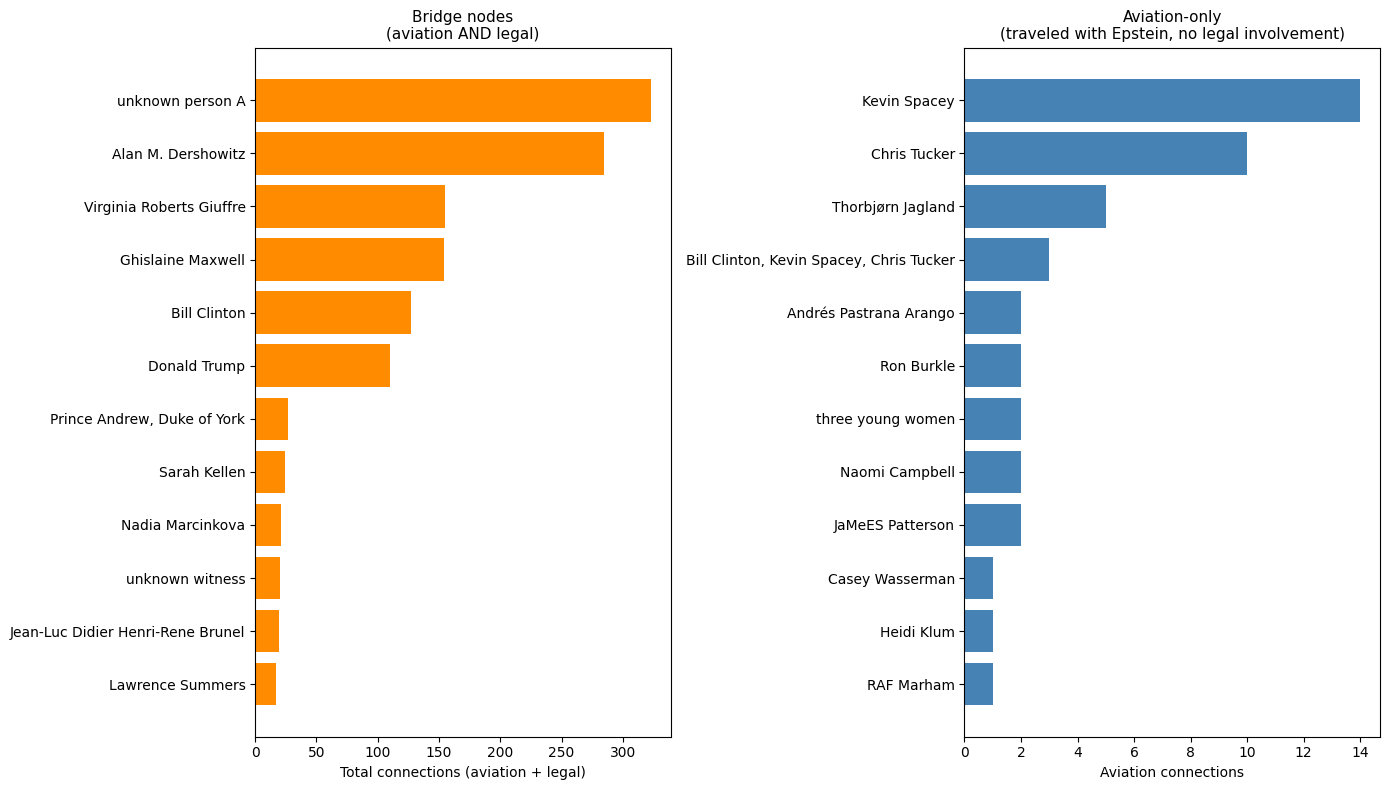

In [64]:
## BAR PLOTS BRIDGE NODES VS AVIATION ONLY 

#  Aviation only — entities without legal connections
aviation_only = bridge_nodes[bridge_nodes['legal_count'] == 0].copy()

# Bridge nodes — entities both in legal and aviation network
bridge_only = bridge_nodes[bridge_nodes['legal_count'] > 0].copy()
# Verwijder Epstein zelf
bridge_only = bridge_only[bridge_only['entity'] != 'Jeffrey Epstein']

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Bridge nodes
top_bridge = bridge_only.head(12)
axes[0].barh(top_bridge['entity'][::-1], top_bridge['total'][::-1], color='darkorange')
axes[0].set_xlabel('Total connections (aviation + legal)')
axes[0].set_title('Bridge nodes\n(aviation AND legal)', fontsize=11)

# Aviation only
top_avi_only = aviation_only.head(12)
axes[1].barh(top_avi_only['entity'][::-1], top_avi_only['connection_count'][::-1], color='steelblue')
axes[1].set_xlabel('Aviation connections')
axes[1].set_title('Aviation-only\n(traveled with Epstein, no legal involvement)', fontsize=11)

plt.tight_layout()
plt.show()